**Provo l combinazione di due grating con guida di collegamento**

In [2]:
import sax
import jax.numpy as jnp
from jax.typing import ArrayLike
from simphony.libraries import siepic 
from simphony.classical import ClassicalSim

In [3]:
linea1, info = sax.circuit(
    netlist={
        "instances": {
            "grat_in": "grat",
            "wg": "wg",
            "grat_out": "grat",
        },
        "connections": {
            "grat_in,o0": "wg,o0",
            "wg,o1": "grat_out,o1",
        },
        "ports": {
            "in": "grat_in,o1",
            "out": "grat_out,o0",
        },
    },
    models={
        "wg": siepic.waveguide,
        "grat": siepic.grating_coupler,
    }
)

In [4]:
## PROVE GENERICHE
wl = 1.55;
## wl = jnp.linspace(1.5, 1.6, 1000)
S = linea1(wl=wl, wg={"length": 1000.0})
mag = jnp.abs(S["out", "in"])**2
print(S["out", "in"]) ## PARAMETRO S IN AMPIEZZA TRA USCITA E INGRESSO
print(mag)  ## È LA POTENZA

[0.07209003-0.57015139j]
[0.33026957]


**il risultato precedente è stato ricavato con una guida ideale secondo la libreria SiEPIC che non usa indci efficaci e possiede perdite pari a 0 db/cm**

In [5]:
## impostiamo le lunghezze d'onda da simulare
wl = jnp.linspace(1.5,1.6,1000)

In [8]:
sim = ClassicalSim(ckt=linea1, wl=wl, wg={"length":1000.0})
laser = sim.add_laser(ports=["in"], power=1.0)
detector = sim.add_detector(ports=["out"])

In [9]:
result = sim.run()

<Axes: xlabel='Wavelength (um)', ylabel='Power (mW)'>

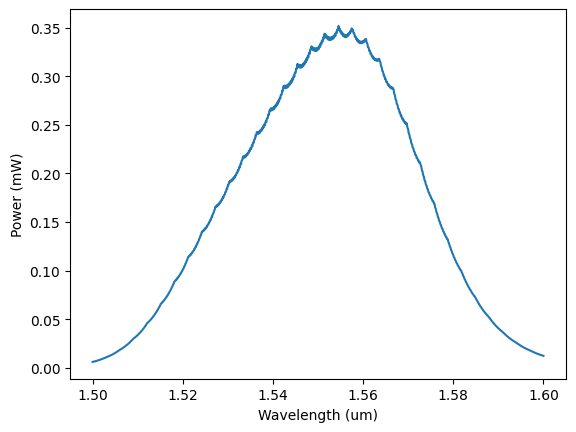

In [10]:
result.detectors["out"].plot()